In [29]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt

In [30]:
df = pd.read_csv(r"C:\brijesh data\swiggy.csv")
df.head()

,App,review_date,review_description,rating,thumbsUpCount,developer_response,developer_response_date,appVersion
0,Swiggy,2023-07-24 09:57:40,I have been using swiggy for a long time and I...,2,103,"Hey there, we apologize for the inconvenience ...",2023-07-24 10:02:21,4.37.2
1,Swiggy,2023-07-23 10:35:23,Worst experiences I'm having with the app for ...,1,12,"Hello, we would like to know more about it. Pl...",2023-07-23 10:42:22,4.37.2
2,Swiggy,2023-07-24 14:48:26,The best foolishing app with offers. The app o...,1,7,We are sorry to let you down. Please write to ...,2023-07-24 14:52:22,4.37.2
3,Swiggy,2023-07-07 08:26:00,Title: Disappointing Experience with Swiggy In...,1,85,"Hey there, we are sorry to have put you throug...",2023-07-07 08:32:20,4.36.1
4,Swiggy,2023-07-19 07:40:05,Worst ever experience. I ordered from instamar...,1,29,We're apologetic about this experience you've ...,2023-07-19 07:42:22,4.36.3


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200791 entries, 0 to 200790
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   App                      200791 non-null  str  
 1   review_date              200791 non-null  str  
 2   review_description       200791 non-null  str  
 3   rating                   200791 non-null  int64
 4   thumbsUpCount            200791 non-null  int64
 5   developer_response       197247 non-null  str  
 6   developer_response_date  197247 non-null  str  
 7   appVersion               170082 non-null  str  
dtypes: int64(2), str(6)
memory usage: 83.9 MB


In [32]:
df.isnull().sum()

App                            0
review_date                    0
review_description             0
rating                         0
thumbsUpCount                  0
developer_response          3544
developer_response_date     3544
appVersion                 30709
dtype: int64

In [33]:
df["developer_response"] = df["developer_response"].fillna("No response")
df["developer_response_date"] = df["developer_response_date"].fillna("No response")
df["appVersion"] = df["appVersion"].fillna("Unknown")

# Step 2: Duplicate rows hata do
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

print("Rows after cleaning:", len(df))
df.isnull().sum()

Duplicates: 0
Rows after cleaning: 200791


App                        0
review_date                0
review_description         0
rating                     0
thumbsUpCount              0
developer_response         0
developer_response_date    0
appVersion                 0
dtype: int64

In [34]:

def clean_text(text):
    text = text.lower()                   
    text = text.replace("'", "")           
    text = re.sub(r"[^a-z\s]", " ", text)  
    text = re.sub(r"\s+", " ", text)       
    return text.strip()

df["clean_review"] = df["review_description"].apply(clean_text)

# Before / After
print("Original:", df["review_description"].iloc[1])
print()
print("Cleaned :", df["clean_review"].iloc[1])

Original: Worst experiences I'm having with the app for last couple of months...but today's was worst. Such a irresponsible delivery partner,app is worst and the customer support was horrible. I don't even prefer giving 1 rating but wanted to put my feedback and app asked for feedback... I hope better competition these people would have soon apart from Zomato to take them off Market... Also a good salute to delivery partners who worked hard than what I had experienced.

Cleaned : worst experiences im having with the app for last couple of months but todays was worst such a irresponsible delivery partner app is worst and the customer support was horrible i dont even prefer giving rating but wanted to put my feedback and app asked for feedback i hope better competition these people would have soon apart from zomato to take them off market also a good salute to delivery partners who worked hard than what i had experienced


In [35]:
critical_reviews = df[df["rating"] <= 2].copy()
print("Number of critical reviews:", len(critical_reviews))
critical_reviews["rating"].value_counts().sort_index()

Number of critical reviews: 110949


rating
1    101539
2      9410
Name: count, dtype: int64

In [36]:

df["rating"].value_counts().sort_index()

rating
1    101539
2      9410
3      8732
4     15399
5     65711
Name: count, dtype: int64

In [37]:

stopwords = {
    "the", "and", "to", "i", "is", "they", "for", "of", "my", "a", "in", "it", "this", "very",
    "you", "your", "but", "are", "have", "from", "was", "with", "on", "that", "me", "be", "not",
    "so", "we", "had", "been", "were", "or", "as", "at", "all", "can", "will", "its", "after",
    "when", "even", "one", "get", "got", "their", "than", "then", "just", "there", "any", "also",
    "more", "dont", "cant", "didnt", "im", "ive", "would", "what", "which", "who", "has", "do",
    "app", "swiggy", "zomato"
}


def get_top_keywords(reviews, top_n=15):
    words = []
    for review in reviews:
        for word in review.split():
            if word not in stopwords and len(word) >= 3:
                words.append(word)
    return Counter(words).most_common(top_n)

top_complaints = get_top_keywords(critical_reviews["clean_review"])

top_complaints_df = pd.DataFrame(top_complaints, columns=["Keyword", "Frequency"])
top_complaints_df

,Keyword,Frequency
0,order,63578
1,delivery,50558
2,food,39547
3,service,32539
4,worst,29864
5,customer,29338
6,time,27569
7,bad,19673
8,experience,15602
9,money,14026


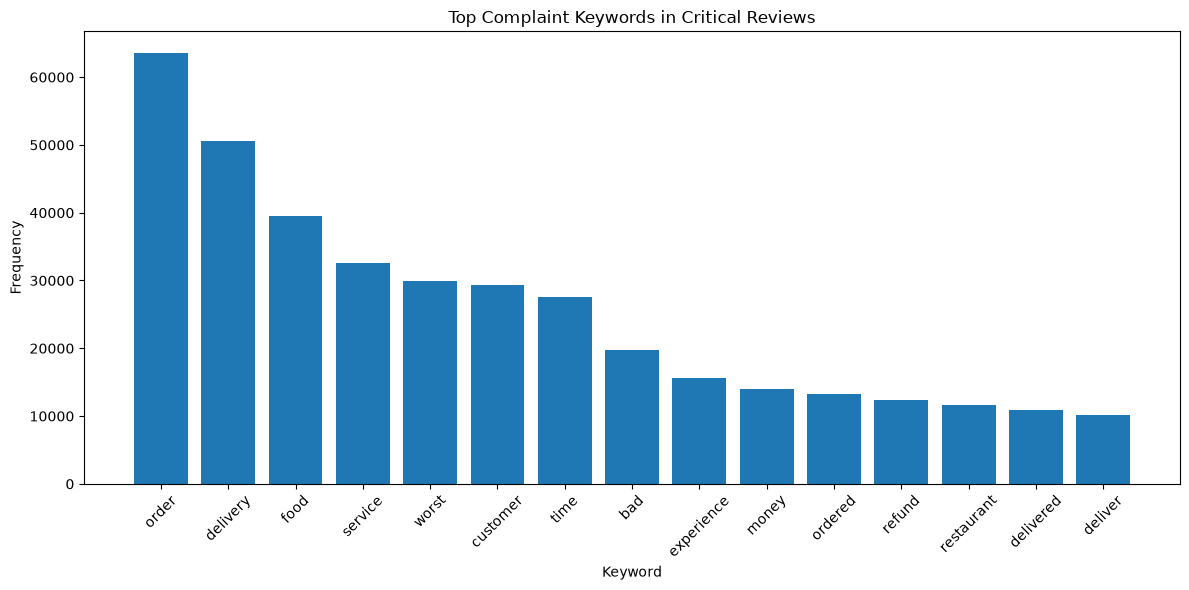

In [38]:
# Bar chart
plt.figure(figsize=(12, 6))
plt.bar(top_complaints_df["Keyword"], top_complaints_df["Frequency"])
plt.title("Top Complaint Keywords in Critical Reviews")
plt.xlabel("Keyword")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
total_reviews = len(df)
critical_count = len(critical_reviews)

print("Total Reviews:", total_reviews)
print("Critical Reviews (1-2 stars):", critical_count)
print("Critical Review Percentage:", round(critical_count / total_reviews * 100, 2), "%")
print("Average Rating:", round(df["rating"].mean(), 2))
print()
print("Top 10 Complaint Keywords:")
for keyword, count in top_complaints[:10]:
    print(keyword, ":", count)

Total Reviews: 200791
Critical Reviews (1-2 stars): 110949
Critical Review Percentage: 55.26 %
Average Rating: 2.67

Top 10 Complaint Keywords:
order : 63578
delivery : 50558
food : 39547
service : 32539
worst : 29864
customer : 29338
time : 27569
bad : 19673
experience : 15602
money : 14026


In [40]:

critical_reviews["review_length"] = critical_reviews["review_description"].str.split().str.len()


selected_reviews = critical_reviews.sort_values(by="review_length", ascending=False).head(3).copy()

selected_reviews[["rating", "review_length", "review_description"]]


,rating,review_length,review_description
18983,1,448,I switched over from Uber eats and long story ...
32180,1,337,Today l have ordered two food items( pre paid ...
126117,1,333,I tried making making an order for my dinner a...


In [41]:
for idx, row in selected_reviews.iterrows():
    print("=" * 80)
    print("Review ID:", idx, "| Rating:", row["rating"], "| Words:", row["review_length"])
    print()
    print(row["review_description"])
    print()

Review ID: 18983 | Rating: 1 | Words: 448

I switched over from Uber eats and long story short, I'm terribly disappointed with Swiggy's approach to customers. For delayed deliveries their customer support is extremely aggressive in ensuring the customer is the one to bear the loss. In other cases that I've read on social media, Swiggy won't protect customers if the food is of poor quality. So why do we put up with this? I placed an order for lunch at 12pm. I know occasionally deliveries can be delayed, so I plan ahead. I pay using my credit card and step back. The app shows the delivery person reached the restaurant and then no update for a while. At 1pm the delivery guy shows up at my door with the wrong order. I let him know it's the wrong order and he pretends to be surprised for a few seconds, says '2mins' and vanishes. It's 1.30pm now, there's been no update and I've lost any hope of getting my lunch. There's been no update from their CS either. So, I reach out to their CS and ask

## . Generative AI - Apology Emails


In [42]:
!pip install -U google-genai

   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   -------- ------------------------------- 0.3/1.2 MB ? eta -:--:--
   ----------------- ---------------------- 0.5/1.2 MB 724.1 kB/s eta 0:00:01
   ----------------- ---------------------- 0.5/1.2 MB 724.1 kB/s eta 0:00:01
   ----------------- ---------------------- 0.5/1.2 MB 724.1 kB/s eta 0:00:01
   ----------------- ---------------------- 0.5/1.2 MB 724.1 kB/s eta 0:00:01
   -------------------------- ------------- 0.8/1.2 MB 473.9 kB/s eta 0:00:01
   ----------------------------------- ---- 1.0/1.2 MB 564.4 kB/s eta 0:00:01
   ---------------------------------------- 1.2/1.2 MB 599.2 kB/s  0:00:01
  Attempting uninstall: google-genai
    Found existing installation: google-genai 2.28.0
    Uninstalling google-genai-2.28.0:
      Successfully uninstalled google-genai-2.28.0


In [58]:
from google import genai
from getpass import getpass
import os

os.environ["GEMINI_API_KEY"] = getpass("ENTER YOUR API KEY ")

client = genai.Client(
    api_key=os.environ["GEMINI_API_KEY"]
)

print("Gemini client connected successfully!")

AQ.Ab8RN6JF0mOo5862NmtmurBqllTd1h2gVcyaIygBFu6_P2T_DQ  ········


Gemini client connected successfully!


In [51]:
response = client.models.generate_content(
    model="gemini-3.5-flash",
    contents="Say hello in one short sentence."
)

print(response.text)

Hello, how can I help you today?


In [52]:
models = client.models.list()

for model in models:
    if "generateContent" in str(model.supported_actions):
        print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-nano-banana-2.1
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-omni-1.1-flash
models/gemini-3.5-transcribe
models/gemini-3.6-flash
models/gemini-3.7-flash
models/gemini-3.8-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/lyria-3.5
models/gemini

In [53]:
def generate_email_gemini(review_text):
    prompt = f"""
You are a professional customer support agent.

Write a short, personalized and empathetic apology email based ONLY on the customer review below.

Customer review:
{review_text}

Requirements:
- Include a subject line.
- Address the customer's specific complaints.
- Apologize sincerely and show empathy.
- Do not invent facts.
- Do not promise refunds, coupons, compensation, or actions not mentioned in the review.
- Keep the email around 150-200 words.
- End with:
Sincerely,
Customer Support Team
"""

    response = client.models.generate_content(
        model="gemini-3.5-flash",
        contents=prompt
    )

    return response.text

In [54]:
gemini_emails = {}

for idx, row in selected_reviews.iterrows():
    try:
        gemini_emails[idx] = generate_email_gemini(row["review_description"])
        
        print("=" * 80)
        print(f"Email for Review ID {idx}")
        print()
        print(gemini_emails[idx])
        print()

    except Exception as e:
        print("=" * 80)
        print(f"Generation failed for Review ID {idx}: {e}")

Email for Review ID 18983

Subject: Sincere apology regarding your recent lunch order experience

Dear Customer,

We are deeply sorry for the incredibly frustrating experience you had with your lunch order. We understand how disappointing it was to plan ahead by ordering at 12 PM, only to receive the wrong items at 1 PM, and have the delivery partner disappear. Leaving you hungry and without updates by 1:30 PM is completely unacceptable. 

Furthermore, we sincerely apologize for the distressing interaction with our customer support. It is deeply regrettable that after agreeing to a full refund over chat, our agent went back on their word and reverted to a 50% coupon offer. We completely understand why you refused the delayed parcel based on that prior agreement, and we are truly sorry for breaking your trust. 

We take your feedback regarding our treatment of prepaid customers, delivery delays, and overall support approach very seriously. Thank you for sharing your experience, and we a

## 7. Final Output - 3 Gemini Generated Emails

The following three personalized apology emails were generated using Google Gemini based on the selected critical reviews.

### Email 1 - Review 18983

**Subject: Sincere Apologies for Your Recent Experience**

Dear Customer,

I am incredibly sorry for the deeply frustrating experience you had with your lunch order. You planned ahead by ordering at 12:00 PM, only to receive the wrong order at 1:00 PM, have the delivery partner vanish, and be left waiting for over 90 minutes with no proactive updates from us.

Furthermore, I am sincerely sorry for how our customer support team handled your refund request. It is deeply regrettable that after initially offering a 50% coupon, our agent promised you a refund over chat, only to renege on that agreement after you rightfully refused the delayed parcel. Going back on our word and leaving you feeling cheated after you prepaid with your credit card is a severe failure on our part.

We completely understand your disappointment and why you have lost trust in our service and brand. Please accept our sincerest apologies for letting you down so completely during this entire interaction.

Sincerely,
Customer Support Team

### Email 2 - Review 32180

**Subject: Sincere Apologies Regarding Your Recent Delivery Experience**

Dear Customer,

We are deeply sorry for the distressing experience you had with your recent prepaid order of two food items. Hearing about the ordeal you underwent is truly disappointing, and we sincerely apologize for the frustration this has caused.

It is completely unacceptable that the delivery executive did not arrive at your address, remained parked in Sanjogi byelane, and that the contact number provided connected you to a stranger miles away. You should never have had to search for your delivery. Furthermore, we are incredibly sorry for the executive's behavior when you confronted him—including making navigation excuses, initially refusing to hand over your food, and demanding your phone number and a photograph of you holding the items.

We completely understand why this disrespectful and uncomfortable situation has caused you to lose faith in our online transactions. Respecting our customers is of the utmost importance, and we deeply regret failing to provide you with a safe and seamless experience.

Sincerely,
Customer Support Team

### Email 3 - Review 126117

**Subject: Sincere Apologies Regarding Your Dinner Order**

Dear Customer,

I am incredibly sorry for the frustrating experience you had when trying to order dinner at 10 PM. I completely understand how upsetting it is to wait hungrily for over an hour and a half, only to have your order cancelled.

It is unacceptable that the delivery partner remained stationary, ignored your calls from multiple numbers, and that you were given a highly questionable explanation about the police stopping them and snatching your food. You deserved honest, timely communication, especially since you even offered to locate the driver yourself. Furthermore, I deeply regret that this is the third time you have faced this very same issue. Your loss of patience is entirely justified, and this is absolutely not the standard of service we aim to provide.

Thank you for bringing this to our attention. We are truly sorry for letting you down so severely when you were relying on us.

Sincerely,
Customer Support Team


## . Key Insights (Summary)

- The dataset contains reviews with ratings from **1 to 5 stars**, and **1-star reviews** are the most common.
- **Critical reviews (1–2 stars)** make up more than half of the dataset. The exact numbers are shown in the output of Section 4.
- The most common complaint keywords are **order, delivery, food, customer, worst, service, time, bad, money, and refund**, indicating that major problems are related to **orders, delivery, customer service, and refunds**.
- AI was used to generate **personalized apology emails** for the **3 most detailed critical reviews**.